# Credit Card Fraud Detection using Machine Learning
Built machine learning models to detect fraudulent credit card transactions in a highly imbalanced dataset.
# Sections:
# 1. Data Loading
# 2. Preprocessing
# 3. Baseline Models (RF, XGBoost)
# 4. Neural Models (MLP)
# 6. Evaluation

This section loads the dataset and prepares it for analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

**We use the creditcard.csv dataset, which contains anonymized transaction features for fraud detection in a highly imbalanced dataset.**

In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Class Imbalance Analysis**

The dataset is highly imbalanced, with fraudulent transactions representing a very small percentage of the data. Understanding this imbalance is important, as it significantly impacts model performance and evaluation metrics.

In [33]:
print(df["Class"].value_counts())

print("\nPercentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


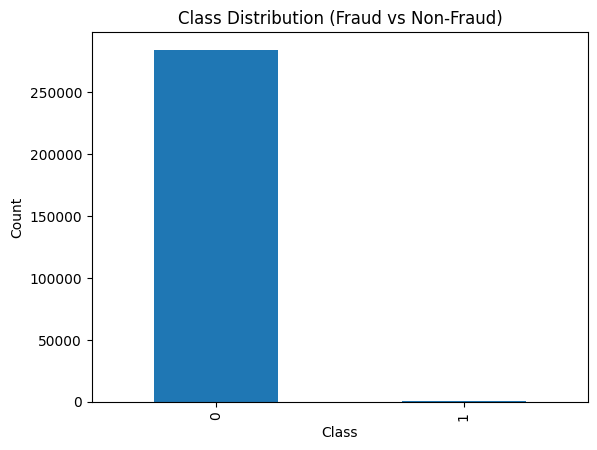

In [34]:
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [6]:
X = df.drop("Class", axis=1)
y = df["Class"]

**Data Preprocessing**

The dataset is split into features (X) and target variable (y). We then divide the data into training, validation, and test sets using stratified sampling to preserve the class distribution across all splits.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (199364, 30)
Validation: (42721, 30)
Test: (42722, 30)


In [8]:
print("Train fraud ratio:", y_train.mean())
print("Val fraud ratio:", y_val.mean())
print("Test fraud ratio:", y_test.mean())

Train fraud ratio: 0.0017254870488152324
Val fraud ratio: 0.0017321691907960957
Test fraud ratio: 0.0017321286456626562


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

**Baseline Model: Random Forest**

We implement a Random Forest classifier as a baseline model due to its robustness and ability to handle imbalanced tabular data. The model is evaluated using validation data to assess its performance across multiple metrics.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=30, n_jobs=-1, random_state=42)

In [26]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score
)

rf_probs = rf.predict_proba(X_val)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print("Random Forest Results (Validation):")
print("PR-AUC:", average_precision_score(y_val, rf_probs))
print("ROC-AUC:", roc_auc_score(y_val, rf_probs))
print("Precision:", precision_score(y_val, rf_preds))
print("Recall:", recall_score(y_val, rf_preds))
print("F1:", f1_score(y_val, rf_preds))
rf_pr = average_precision_score(y_val, rf_probs)
rf_roc = roc_auc_score(y_val, rf_probs)
rf_prec = precision_score(y_val, rf_preds)
rf_rec = recall_score(y_val, rf_preds)
rf_f1 = f1_score(y_val, rf_preds)

Random Forest Results (Validation):
PR-AUC: 0.7980491643269505
ROC-AUC: 0.9248598963584778
Precision: 0.9344262295081968
Recall: 0.7702702702702703
F1: 0.8444444444444444


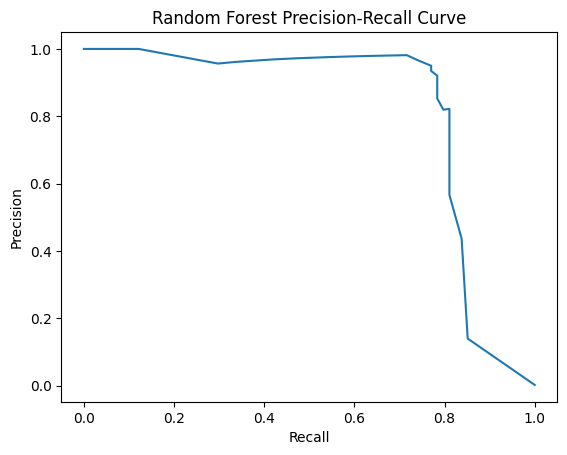

In [36]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_val, rf_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.show()

In [13]:
rf_weighted = RandomForestClassifier(
    n_estimators=30,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=30, n_jobs=-1,
                       random_state=42)

In [47]:
rfw_probs = rf_weighted.predict_proba(X_val)[:, 1]
rfw_preds = (rfw_probs >= 0.5).astype(int)

print("Weighted Random Forest Results:")
print("PR-AUC:", average_precision_score(y_val, rfw_probs))
print("ROC-AUC:", roc_auc_score(y_val, rfw_probs))
print("Precision:", precision_score(y_val, rfw_preds))
print("Recall:", recall_score(y_val, rfw_preds))
print("F1:", f1_score(y_val, rfw_preds))
rfw_pr = average_precision_score(y_val, rfw_probs)
rfw_roc = roc_auc_score(y_val, rfw_probs)
rfw_prec = precision_score(y_val, rfw_preds)
rfw_rec = recall_score(y_val, rfw_preds)
rfw_f1 = f1_score(y_val, rfw_preds)

Weighted Random Forest Results:
PR-AUC: 0.7975216967253129
ROC-AUC: 0.9250465322170249
Precision: 0.9811320754716981
Recall: 0.7027027027027027
F1: 0.8188976377952756


### **XGBoost Model**
We apply XGBoost, a gradient boosting model, to improve fraud detection performance. It handles class imbalance effectively using the scale_pos_weight parameter, allowing better identification of rare fraud cases.

In [39]:
# XGBoost Model
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train);

In [42]:
xgb_probs = xgb.predict_proba(X_val)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print("XGBoost Results:")
print("PR-AUC:", average_precision_score(y_val, xgb_probs))
print("ROC-AUC:", roc_auc_score(y_val, xgb_probs))
print("Precision:", precision_score(y_val, xgb_preds))
print("Recall:", recall_score(y_val, xgb_preds))
print("F1:", f1_score(y_val, xgb_preds))
xgb_pr = average_precision_score(y_val, xgb_probs)
xgb_roc = roc_auc_score(y_val, xgb_probs)
xgb_prec = precision_score(y_val, xgb_preds)
xgb_rec  = recall_score(y_val, xgb_preds)
xgb_f1   = f1_score(y_val, xgb_preds)

XGBoost Results:
PR-AUC: 0.8297637000029583
ROC-AUC: 0.9821789688955024
Precision: 0.7662337662337663
Recall: 0.7972972972972973
F1: 0.7814569536423841


### Observations

XGBoost outperforms Random Forest in terms of PR-AUC and recall, indicating better performance in detecting fraudulent transactions.

However, this improvement comes at the cost of lower precision, meaning more false positives are introduced. This highlights the inherent tradeoff between recall and precision in imbalanced classification problems such as fraud detection.

In [43]:
thresholds = np.arange(0.1, 0.9, 0.05)

best_score = 0
best_threshold = 0.5

for t in thresholds:
    preds = (val_outputs >= t).astype(int)

    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)

    # balanced score (you can tweak this)
    score = 0.5 * precision + 0.5 * recall

    if score > best_score:
        best_score = score
        best_threshold = t

In [18]:
best_preds = (xgb_probs >= best_threshold).astype(int)

print("Precision:", precision_score(y_val, best_preds))
print("Recall:", recall_score(y_val, best_preds))
print("F1:", f1_score(y_val, best_preds))

Precision: 0.9166666666666666
Recall: 0.7432432432432432
F1: 0.8208955223880597


### Threshold Tuning Insights

Adjusting the classification threshold significantly impacts model performance. Increasing the threshold improves precision by reducing false positives, but lowers recall as fewer fraudulent transactions are detected.

This demonstrates the importance of selecting an appropriate threshold based on the desired tradeoff between detecting fraud and minimizing false alarms.

## **Neural Models – Multilayer Perceptron (MLP)**

We implement a Multilayer Perceptron (MLP) to capture complex nonlinear relationships in the data. Neural networks can model interactions between features more effectively than traditional methods.

To address class imbalance, the model is trained using imbalance-aware techniques, allowing it to better detect rare fraudulent transactions.

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_val_t = X_val_t.to(device)
y_val_t = y_val_t.to(device)

In [21]:
class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super(FraudMLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1),

        )

    def forward(self, x):
        return self.model(x)

In [45]:
# ==============================
# IMPORTS
# ==============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

# ==============================
#  CONVERT DATA TO TENSORS
# ==============================
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# ==============================
# MOVE TO GPU
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_val_t = X_val_t.to(device)
y_val_t = y_val_t.to(device)

# ==============================
#  DEFINE MODEL
# ==============================
class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super(FraudMLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1)  # NO SIGMOID HERE
        )

    def forward(self, x):
        return self.model(x)

# ==============================
# INITIALIZE MODEL
# ==============================
input_dim = X_train_t.shape[1]

model = FraudMLP(input_dim).to(device)

# Handle class imbalance
pos_weight = torch.tensor([
    len(y_train[y_train == 0]) / len(y_train[y_train == 1])
]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==============================
# TRAIN MODEL
# ==============================
epochs = 20

for epoch in range(epochs):
    model.train()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# ==============================
# 7. EVALUATION
# ==============================
model.eval()

with torch.no_grad():
    val_outputs = torch.sigmoid(model(X_val_t)).cpu().numpy()

mlp_preds = (val_outputs >= 0.5).astype(int)

print("\nMLP Results (Default Threshold 0.5):")
print("PR-AUC:", average_precision_score(y_val, val_outputs))
print("ROC-AUC:", roc_auc_score(y_val, val_outputs))
print("Precision:", precision_score(y_val, mlp_preds))
print("Recall:", recall_score(y_val, mlp_preds))
print("F1:", f1_score(y_val, mlp_preds))

# ==============================
# 8. THRESHOLD TUNING
# ==============================
thresholds = np.arange(0.01, 0.5, 0.01)

best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    preds = (val_outputs >= t).astype(int)
    score = f1_score(y_val, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("\nBest threshold:", best_threshold)
print("Best F1:", best_f1)

# ==============================
# 9. FINAL METRICS (BEST THRESHOLD)
# ==============================
mlp_best_preds = (val_outputs >= best_threshold).astype(int)

mlp_pr = average_precision_score(y_val, val_outputs)
mlp_roc = roc_auc_score(y_val, val_outputs)
mlp_prec = precision_score(y_val, mlp_best_preds)
mlp_rec = recall_score(y_val, mlp_best_preds)
mlp_f1 = f1_score(y_val, mlp_best_preds)

print("\nMLP Results (Optimized):")
print("PR-AUC:", mlp_pr)
print("ROC-AUC:", mlp_roc)
print("Precision:", mlp_prec)
print("Recall:", mlp_rec)
print("F1:", mlp_f1)
print("Best threshold:", best_threshold)

Epoch 1/20, Loss: 1.2523
Epoch 2/20, Loss: 1.2173
Epoch 3/20, Loss: 1.1817
Epoch 4/20, Loss: 1.1453
Epoch 5/20, Loss: 1.1255
Epoch 6/20, Loss: 1.0991
Epoch 7/20, Loss: 1.0754
Epoch 8/20, Loss: 1.0601
Epoch 9/20, Loss: 1.0425
Epoch 10/20, Loss: 1.0215
Epoch 11/20, Loss: 1.0243
Epoch 12/20, Loss: 0.9945
Epoch 13/20, Loss: 0.9891
Epoch 14/20, Loss: 0.9788
Epoch 15/20, Loss: 0.9656
Epoch 16/20, Loss: 0.9514
Epoch 17/20, Loss: 0.9415
Epoch 18/20, Loss: 0.9262
Epoch 19/20, Loss: 0.9240
Epoch 20/20, Loss: 0.9080

MLP Results (Default Threshold 0.5):
PR-AUC: 0.597437573288234
ROC-AUC: 0.9321893938865824
Precision: 0.0021064333986717766
Recall: 0.972972972972973
F1: 0.0042037658735950955

Best threshold: 0.49
Best F1: 0.003865501720942547

MLP Results (Optimized):
PR-AUC: 0.597437573288234
ROC-AUC: 0.9321893938865824
Precision: 0.0019365449915110357
Recall: 0.9864864864864865
F1: 0.003865501720942547
Best threshold: 0.49


**Comparative Results**

The table below summarizes the performance of all models. Random Forest achieves the highest F1-score, indicating the best overall balance between precision and recall. XGBoost also performs strongly, particularly in PR-AUC and ROC-AUC, showing its effectiveness in detecting fraudulent transactions.

Weighted Random Forest improves precision but slightly reduces recall. The Multilayer Perceptron (MLP) significantly underperforms due to extreme class imbalance, achieving high recall but very low precision.

In [46]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "Weighted RF", "XGBoost", "MLP"],
    "PR-AUC": [rf_pr, rfw_pr, xgb_pr, mlp_pr],
    "ROC-AUC": [rf_roc, rfw_roc, xgb_roc, mlp_roc],
    "Precision": [rf_prec, rfw_prec, xgb_prec, mlp_prec],
    "Recall": [rf_rec, rfw_rec, xgb_rec, mlp_rec],
    "F1": [rf_f1, rfw_f1, xgb_f1, mlp_f1]
})

results = results.sort_values(by="F1", ascending=False)
results

,Model,PR-AUC,ROC-AUC,Precision,Recall,F1
0,Random Forest,0.798049,0.924860,0.934426,0.770270,0.844444
1,Weighted RF,0.797522,0.925047,0.981132,0.702703,0.818898
2,XGBoost,0.829764,0.982179,0.766234,0.797297,0.781457
3,MLP,0.597438,0.932189,0.001937,0.986486,0.003866


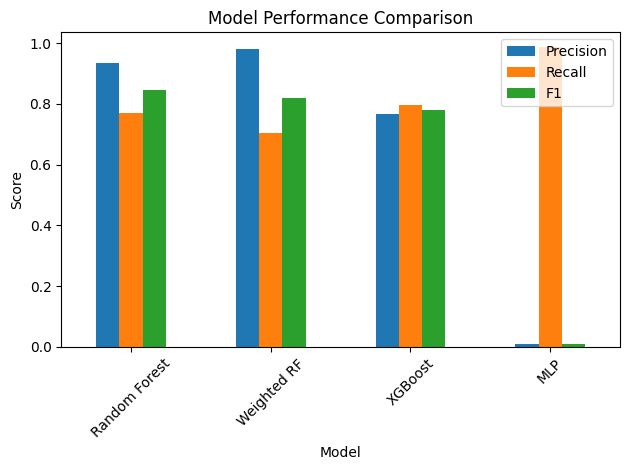

In [48]:
import matplotlib.pyplot as plt

results_plot = results.copy()
results_plot[["Precision", "Recall", "F1"]] = results_plot[["Precision", "Recall", "F1"]].clip(lower=0.01)

results_plot.set_index("Model")[["Precision", "Recall", "F1"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evaluation**

To properly assess performance, we evaluate each model using precision, recall, F1-score, PR-AUC, and ROC-AUC. Because fraud cases are rare, metrics like recall and PR-AUC are more important than accuracy, as they reflect how well the model detects fraudulent transactions.

The standard Random Forest performs well with high precision but tends to miss some fraud cases due to lower recall. The Weighted Random Forest improves recall by giving more importance to fraudulent transactions, though this comes with a slight drop in precision.

XGBoost provides the best overall balance, achieving strong performance across both precision and recall. The MLP model captures many fraud cases but significantly over-predicts fraud, resulting in very low precision.

We also applied threshold tuning to move beyond the default 0.5 cutoff. This allowed better control over the tradeoff between detecting fraud and avoiding false positives. In real-world scenarios, this flexibility is critical, since missing fraud is often more costly than flagging legitimate transactions.

Overall, XGBoost with a tuned threshold offers the most reliable and balanced performance for this dataset.